In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy
import scipy.stats as scs

### Preparing the data

In [2]:
data = pd.read_csv('merged_resale_dataset.csv', index_col = 0)
data.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,mrt_walking_distance,dist_to_cbd_m,mature_estate,region,dist_nearest_park_m,sora_monthly_avg,flat_type_encoded,dist_nearest_hawker_centre_m,Unnamed: 0,Per_Capita_GDP
0,2015-01,PASIR RIS,3 ROOM,5,CHANGI VILLAGE RD,01 TO 03,66.0,Improved,1981,65,...,5753.0,19027.606318,Mature,OCR,230.465816,0.143986,3,159.041158,NaN,76503.0
1,2015-02,PASIR RIS,3 ROOM,4,CHANGI VILLAGE RD,04 TO 06,66.0,Improved,1980,64,...,5753.0,19098.377479,Mature,OCR,172.217395,0.280122,3,87.190607,NaN,76503.0
2,2015-04,PASIR RIS,3 ROOM,5,CHANGI VILLAGE RD,01 TO 03,66.0,Improved,1981,65,...,5753.0,19027.606318,Mature,OCR,230.465816,0.240238,3,159.041158,NaN,76503.0
3,2015-05,PASIR RIS,3 ROOM,5,CHANGI VILLAGE RD,04 TO 06,66.0,Improved,1981,65,...,5753.0,19027.606318,Mature,OCR,230.465816,0.223585,3,159.041158,NaN,76503.0
4,2015-07,KALLANG/WHAMPOA,3 ROOM,93,WHAMPOA DR,04 TO 06,65.0,Improved,1974,57,...,2519.0,4260.806033,Mature,RCR,907.167612,0.219414,3,90.391147,NaN,76503.0


In [3]:
resale_price = pd.to_numeric(data['resale_price'], errors='coerce').dropna()
resale_price.head()

0    290000
1    280000
2    275000
3    280000
4    285000
Name: resale_price, dtype: int64

## Analysing the Distribution of the Resale Price 

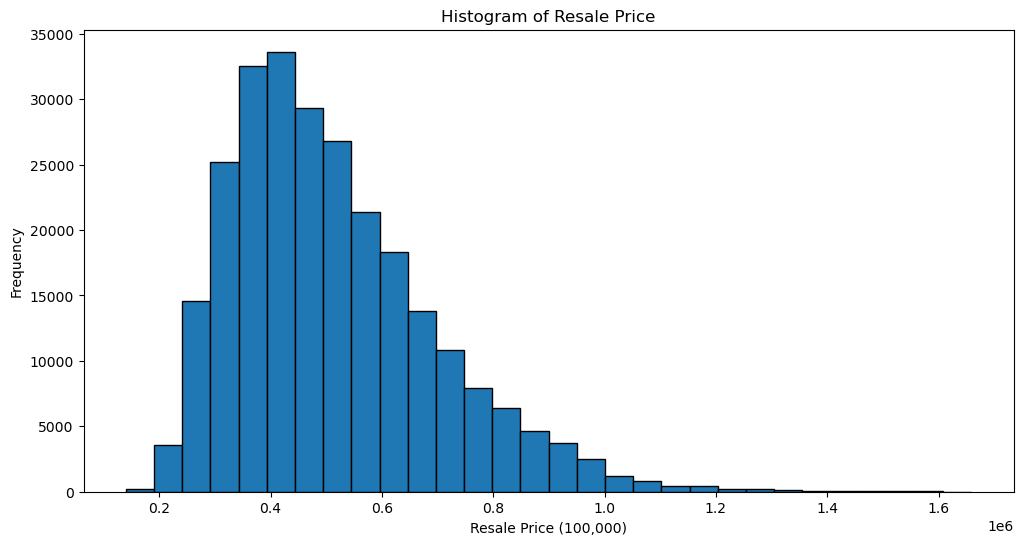

In [7]:
# Histogram
plt.figure(figsize = (12, 6))
plt.hist(resale_price, bins=30, edgecolor='black')
plt.xlabel('Resale Price (100,000)')
plt.ylabel('Frequency')
plt.title('Histogram of Resale Price')
plt.show()

Text(0.5, 1.0, 'Q-Q Plot of Resale Price')

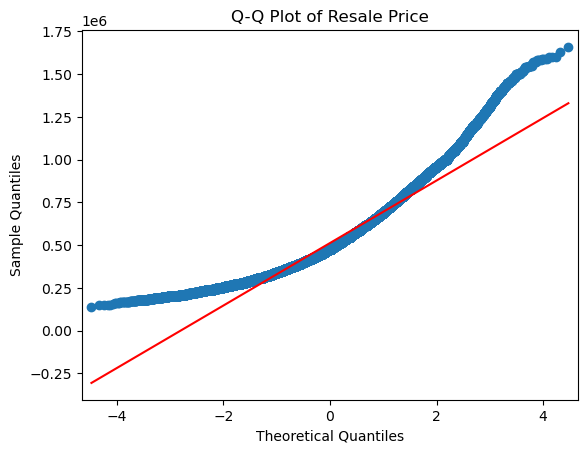

In [8]:
# QQ Plot
sm.qqplot(resale_price, line = 's')
plt.title('Q-Q Plot of Resale Price')

The histogram of resale prices shows a right-skewed distribution. Most observations are concentrated in the lower to middle price range, while a smaller number of high-priced flats create a long right tail. This suggests that resale price is not normally distributed.

The Q-Q plot further shows that the resale price variable does not follow a normal distribution. If the data were normally distributed, the plotted points would lie approximately along the reference straight line. Instead, the points show a clear curved pattern and deviate substantially from the line, especially in the upper quantiles. This indicates that the resale price distribution is positively skewed with a heavy right tail, which is consistent with the histogram.

In [9]:
# Normal Test
stat, p = scs.normaltest(resale_price)

print("Test statistic:", stat)
print("p-value:", p)

Test statistic: 39409.63301342158
p-value: 0.0


In [10]:
# Skew Test
stat, p = scs.skewtest(resale_price)

print("Test statistic:", stat)
print("p-value:", p)

Test statistic: 178.41677472074844
p-value: 0.0


The normality test returned a p-value of approximately 0, which is far below the usual significance level of 0.05. Hence, the null hypothesis of normality is rejected, indicating that resale price does not follow a normal distribution. This is consistent with the histogram and Q-Q plot, which show positive skewness and clear deviation from normality.

Similarly, the skewness test on the untransformed resale price data produced a p-value close to 0, indicating strong evidence against the null hypothesis of zero skewness. This shows that the resale price distribution is significantly skewed. Consistent with the histogram and Q-Q plot, the skewness is positive, reflecting the presence of a long right tail and relatively high-priced observations. This result thus provides statistical support for applying a transformation to reduce skewness and improve the distributional shape of the data.

## Transforming Resale Price to Improve Normality
### Log Transformation

The original resale price distribution is heavily right-skewed and deviates substantially from normality, as indicated by the histogram, Q-Q plot, normality and skew test. Therefore, to ensure normality assumption is held, a logarithmic transformation would be appropriate because it compresses larger values more than smaller values, reducing skewness and improving symmetry. After transformation, the distribution is expected to more closely satisfy the normality assumption required for further analysis and modelling. 

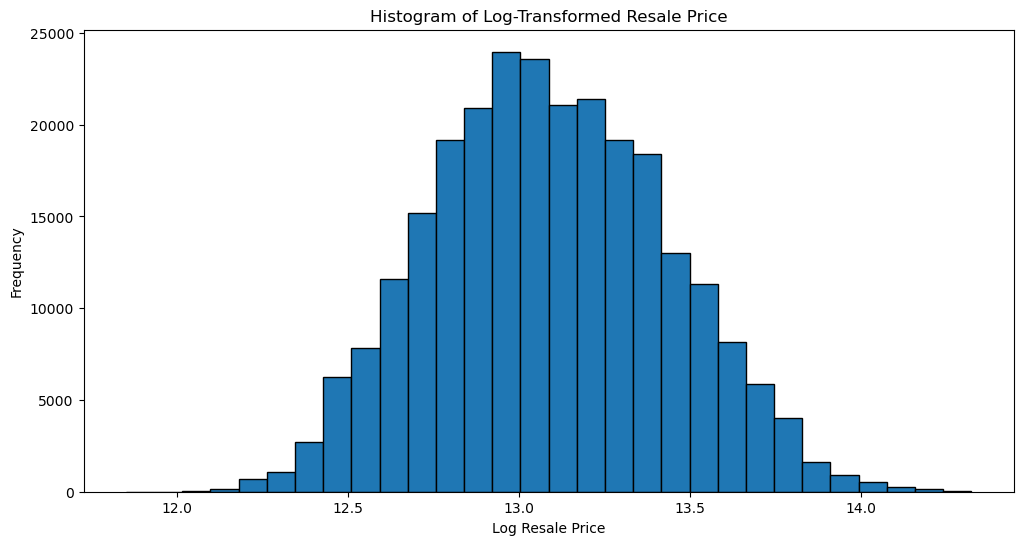

In [15]:
# Applying log transformation
log_price = np.log(resale_price)

# Histogram
log_price.hist(bins=30, edgecolor='black', figsize = (12, 6))
plt.xlabel('Log Resale Price')
plt.ylabel('Frequency')
plt.title('Histogram of Log-Transformed Resale Price')
plt.grid(False)
plt.show();

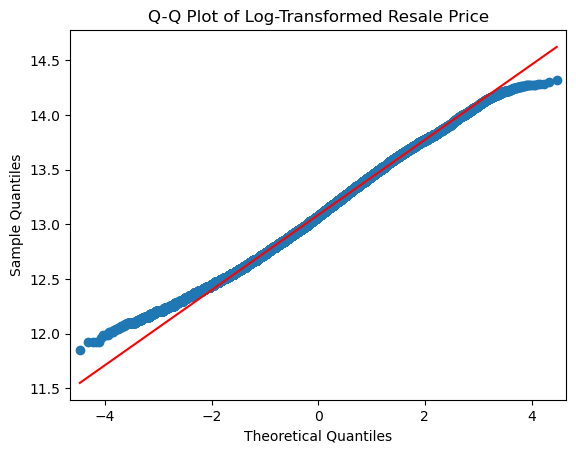

In [12]:
# QQ Plot
sm.qqplot(log_price, line = 's')
plt.title('Q-Q Plot of Log-Transformed Resale Price');

The histogram of log-transformed resale price shows a clear improvement in symmetry relative to the original resale price distribution. The right skewness has been reduced and the distribution appears more approximately normal.

The Q-Q plot of the log-transformed resale price shows a substantial improvement in normality. Most points lie close to the reference line, particularly in the centre of the distribution, indicating that the log transformation has made the data more approximately normal. However, slight deviations remain at the lower and upper tails, suggesting that normality is improved but not perfect.

In [13]:
# Normal Test
stat, p = scs.normaltest(log_price)

print("Test statistic:", stat)
print("p-value:", p)

Test statistic: 2789.0137733800925
p-value: 0.0


In [45]:
# Skew Test
stat, p = scs.skewtest(log_price)

print("Test statistic:", stat)
print("p-value:", p)

Test statistic: 25.496317854346728
p-value: 2.1656020242256207e-143


The log transformation substantially improved the distribution of resale price, making it more symmetric. However, the formal normality test still rejects the null hypothesis of perfect normality, likely because the dataset is very large and the test is highly sensitive to small deviations. Hence, graphical evidence is more informative here, and it is reasonable to conclude that the log transformation improves normality significantly, even if it does not achieve exact normality.

Similarly, the skewness test still produced a p-value close to 0, indicating that some skewness remains. Nevertheless, the test statistic decreased significantly compared with that of the untransformed data, suggesting that the log transformation was effective in reducing the original positive skewness and making the distribution much more symmetric. Hence, although the transformation did not eliminate skewness entirely, it clearly improved the distributional shape of the resale price.

## Conclusion

In summary, the resale price variable was found to be positively skewed and not normally distributed based on the histogram, Q-Q plot, normality and skew test. Applying a log transformation substantially reduced the skewness and produced a distribution that was much closer to normality. While the transformed data still did not achieve perfect normality, the graphical evidence showed clear improvement. Hence, the log transformation was appropriate for improving adherence to the normality assumption and making the resale price variable more suitable for further analysis.